## Yulu, India's pioneering micro-mobility service provider, has embarked on a mission to revolutionize daily commutes by offering unique, sustainable transportation solutions. However, recent revenue setbacks have prompted Yulu to seek the expertise of a consulting company to delve into the factors influencing the demand for their shared electric cycles, specifically in the Indian market.##

In [3]:
import pandas as pd
import numpy as np


In [4]:
df = pd.read_csv('bike_sharing.csv')

In [5]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [8]:
df.shape

(10886, 12)

In [9]:
df.nunique()

datetime      10886
season            4
holiday           2
workingday        2
weather           4
temp             49
atemp            60
humidity         89
windspeed        28
casual          309
registered      731
count           822
dtype: int64

In [10]:
df.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [11]:
df.duplicated().any()

False

i. For Numerical features use Histogram, Distplot, etc.

ii. For Categorical features use Countplot, Pie Chart, etc.

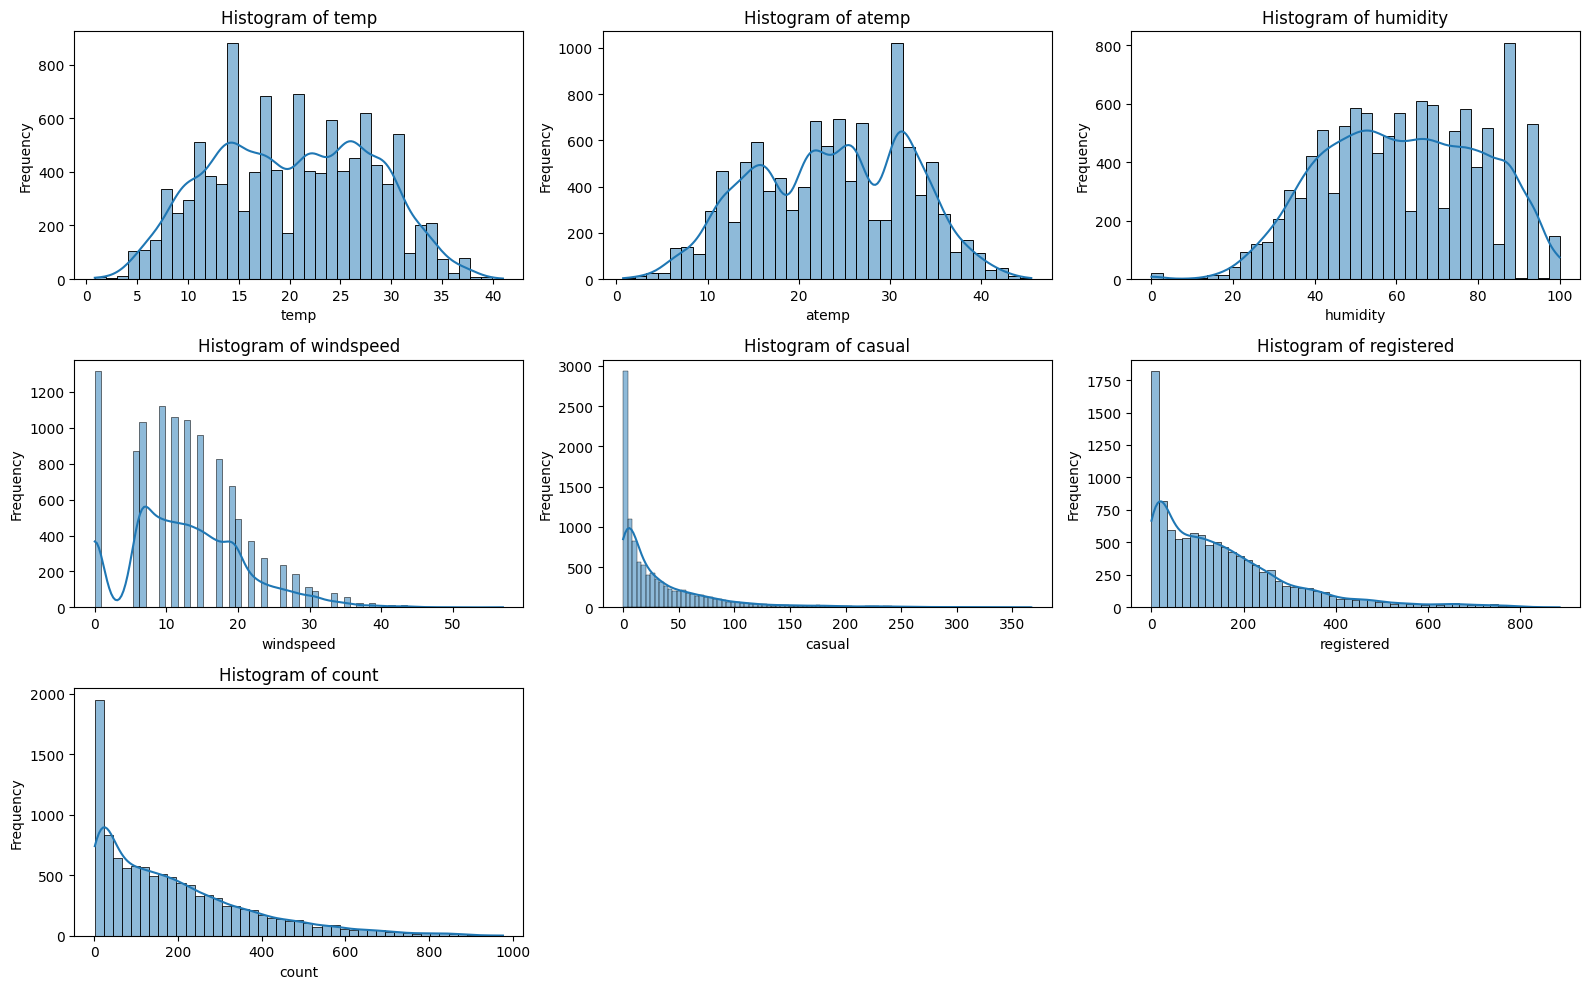

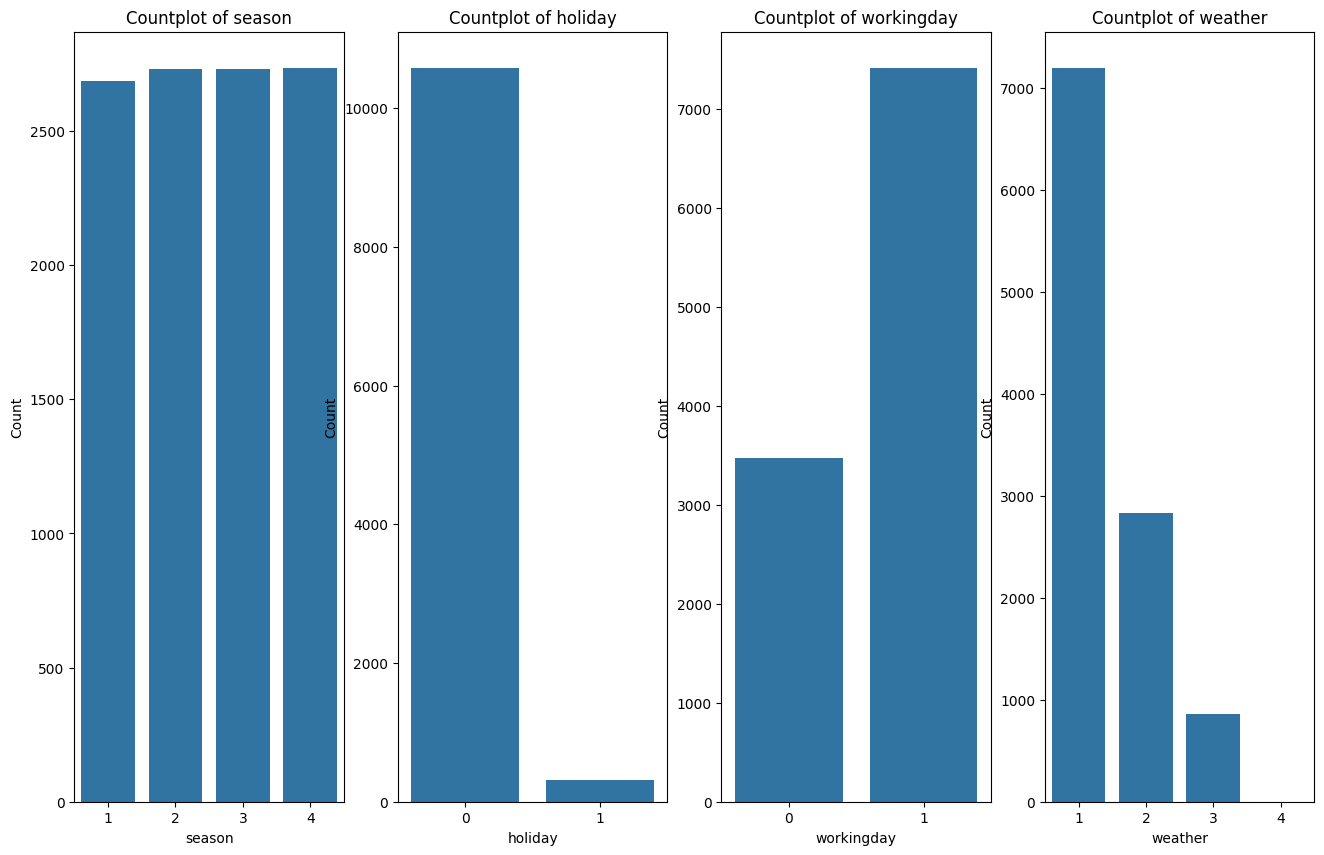

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical Variables
numerical_columns = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
plt.figure(figsize=(16, 10))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[column], kde=True)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Categorical Variables
categorical_columns = ['season', 'holiday', 'workingday', 'weather']
plt.figure(figsize=(16, 10))
for i, column in enumerate(categorical_columns, 1):
    plt.subplot(1, 4, i)
    sns.countplot(x=column, data=df)
    plt.title(f'Countplot of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')

Check for Outliers and deal with them accordingly.

In [22]:
import numpy as np

# Define a function to detect outliers using IQR method
def detect_outliers_iqr(data, threshold=1.5):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers

# Numerical Variables to check for outliers
numerical_columns = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

# Detect outliers for each numerical column
outliers_dict = {}
for column in numerical_columns:
    outliers_dict[column] = detect_outliers_iqr(df[column])

# Print the number of outliers detected for each numerical column
for column, outliers in outliers_dict.items():
    print(f"Number of outliers in {column}: {np.sum(outliers)}")


Number of outliers in temp: 0
Number of outliers in atemp: 0
Number of outliers in humidity: 22
Number of outliers in windspeed: 227
Number of outliers in casual: 749
Number of outliers in registered: 423
Number of outliers in count: 300


In [23]:
# Option 1: Remove Outliers
cleaned_data = df[~outliers_dict['count']]  # Removing outliers from 'count' column
print(f"Data shape after removing outliers: {cleaned_data.shape}")

# Option 2: Clip Outliers
threshold = 1.5  # Adjust as needed
clipped_data = df.copy()
for column, outliers in outliers_dict.items():
    clipped_data[column] = np.where(outliers, np.percentile(df[column], 25), df[column])


Data shape after removing outliers: (10586, 12)


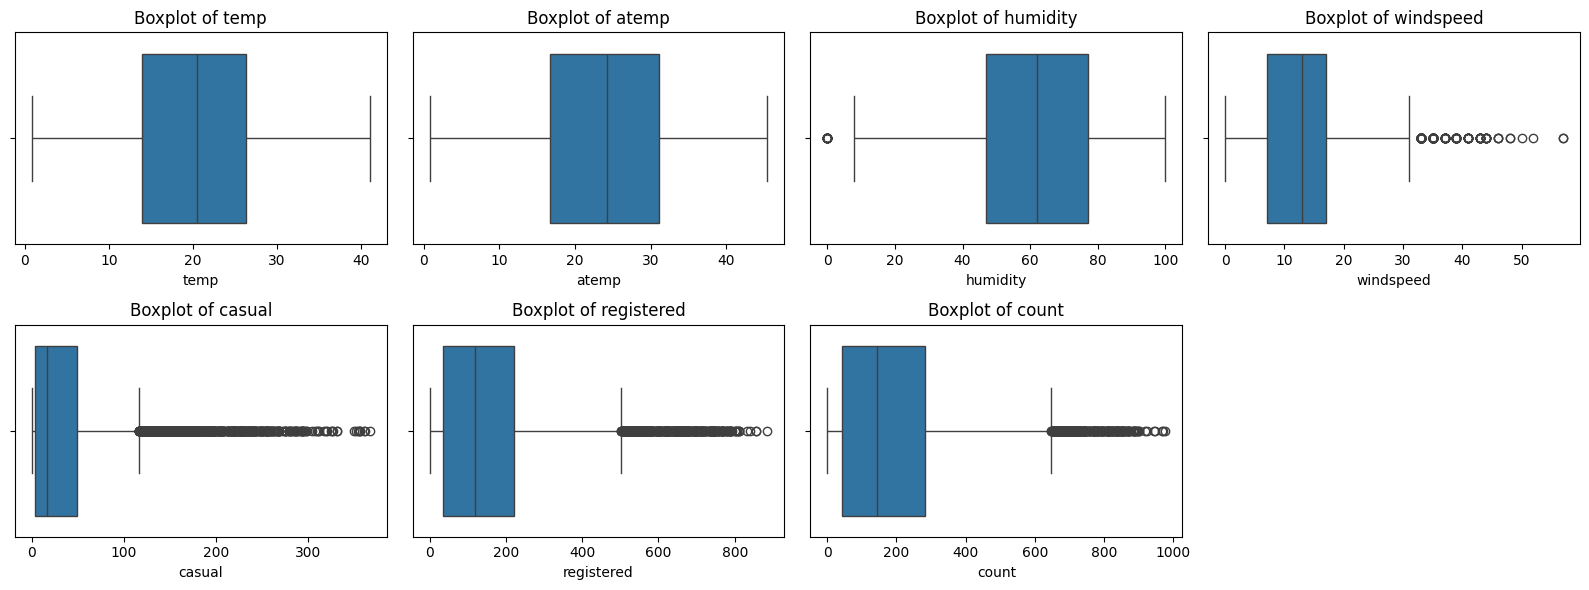

In [25]:
# Visualize boxplots after dealing with outliers
plt.figure(figsize=(16, 6))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
plt.tight_layout()
plt.show()


Try establishing a Relationship between the Dependent and Independent Variables.

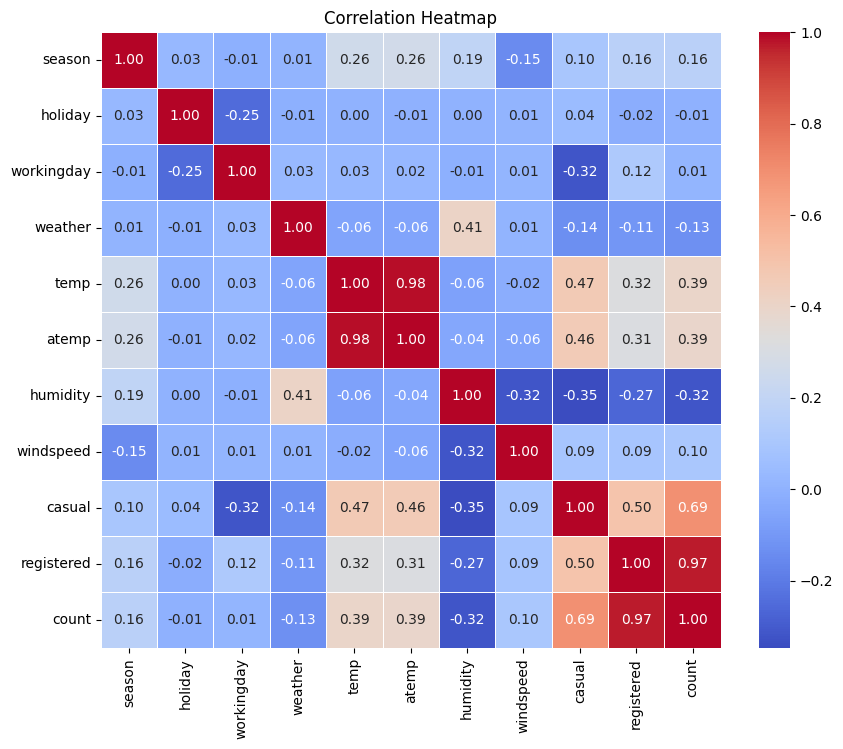

In [31]:
import seaborn as sns

# Remove 'datetime' column before computing correlation matrix
data_for_correlation = df.drop(columns=['datetime'])

# Compute the correlation matrix
corr_matrix = data_for_correlation.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


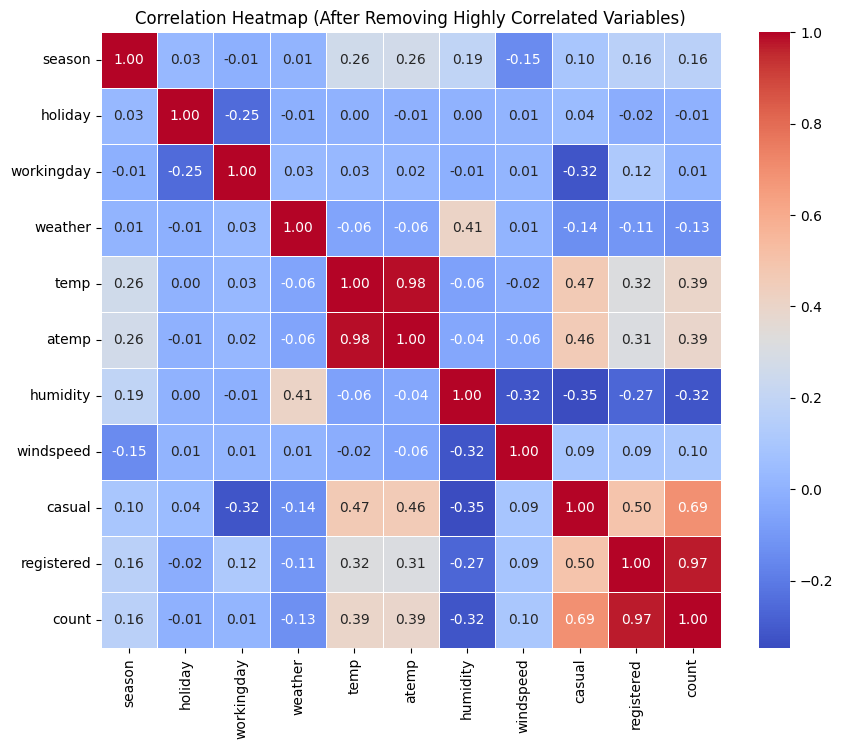

In [40]:
# Remove 'datetime' column before computing correlation matrix
cleaned_data = df.drop(columns=['datetime'])

# Compute the correlation matrix for cleaned data
cleaned_corr_matrix = cleaned_data.corr()

# Plot the correlation heatmap for cleaned data
plt.figure(figsize=(10, 8))
sns.heatmap(cleaned_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (After Removing Highly Correlated Variables)')
plt.show()


3. Check if there any significant difference between the no. of bike rides on Weekdays
and Weekends?

In [47]:
from scipy import stats

# Extracting the counts of bike rides on weekdays and weekends
weekday_counts = df[df['datetime'].dt.dayofweek < 5]['count']
weekend_counts = df[df['datetime'].dt.dayofweek >= 5]['count']

# Performing the 2-sample independent t-test
t_statistic, p_value = stats.ttest_ind(weekday_counts, weekend_counts)

# Setting the significance level (alpha)
alpha = 0.05

# Printing the results
print("T-Statistic:", t_statistic)
print("P-Value:", p_value)

# Decision
if p_value <= alpha:
    print("Reject Null Hypothesis (H0): There is a significant difference in the mean number of bike rides between weekdays and weekends.")
else:
    print("Fail to Reject Null Hypothesis (H0): There is no significant difference in the mean number of bike rides between weekdays and weekends.")



T-Statistic: 1.0354386367292092
P-Value: 0.30048711429228286
Fail to Reject Null Hypothesis (H0): There is no significant difference in the mean number of bike rides between weekdays and weekends.


Looking at the null hyptothesis  -  it suggests that there is no significant difference in the mean number of bike rides between weekdays and weekends.
In such a scenario, it might be appropriate to consider weekdays and weekends as similar in terms of bike ride patterns for planning purposes.




In [48]:
from scipy import stats

# Extracting demand for bicycles on rent for different weather conditions
weather_1 = df[df['weather'] == 1]['count']
weather_2 = df[df['weather'] == 2]['count']
weather_3 = df[df['weather'] == 3]['count']
weather_4 = df[df['weather'] == 4]['count']

# Performing one-way ANOVA test
f_statistic, p_value = stats.f_oneway(weather_1, weather_2, weather_3, weather_4)

# Setting the significance level (alpha)
alpha = 0.05

# Printing the results
print("F-Statistic:", f_statistic)
print("P-Value:", p_value)

# Decision
if p_value <= alpha:
    print("Reject Null Hypothesis (H0): The demand for bicycles on rent varies significantly across different weather conditions.")
else:
    print("Fail to Reject Null Hypothesis (H0): The demand for bicycles on rent is the same across different weather conditions.")


F-Statistic: 65.53024112793271
P-Value: 5.482069475935669e-42
Reject Null Hypothesis (H0): The demand for bicycles on rent varies significantly across different weather conditions.


Normality Test for Weather 1:


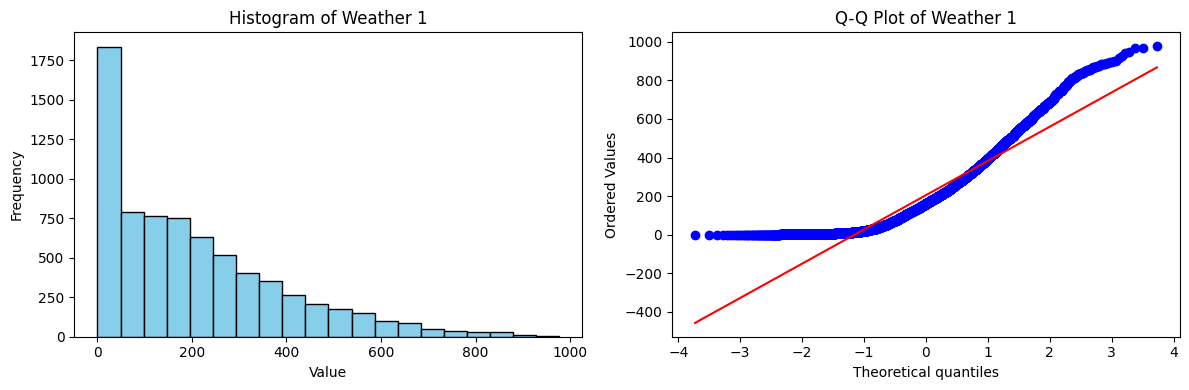

Skewness: 1.14
Kurtosis: 0.96
Shapiro-Wilk's Test p-value: 0.0000
The data does not look normally distributed (Reject the null hypothesis).
Normality Test for Weather 2:


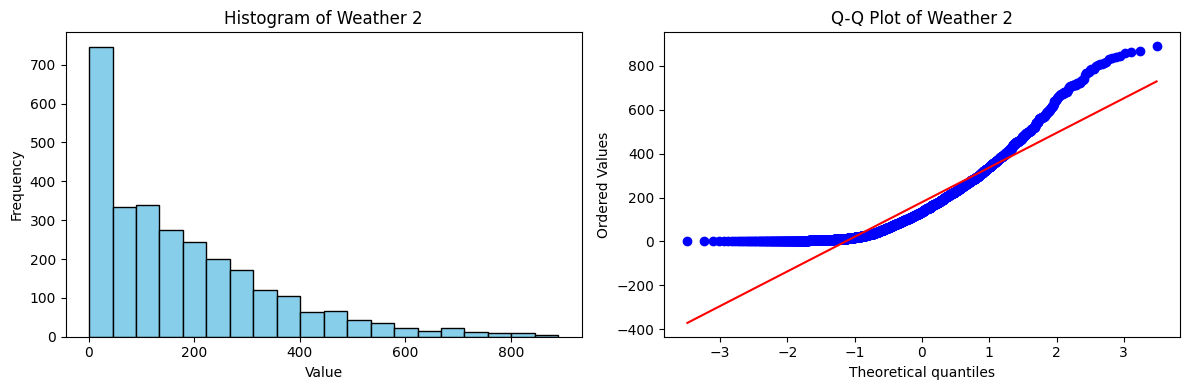

Skewness: 1.29
Kurtosis: 1.59
Shapiro-Wilk's Test p-value: 0.0000
The data does not look normally distributed (Reject the null hypothesis).
Normality Test for Weather 3:


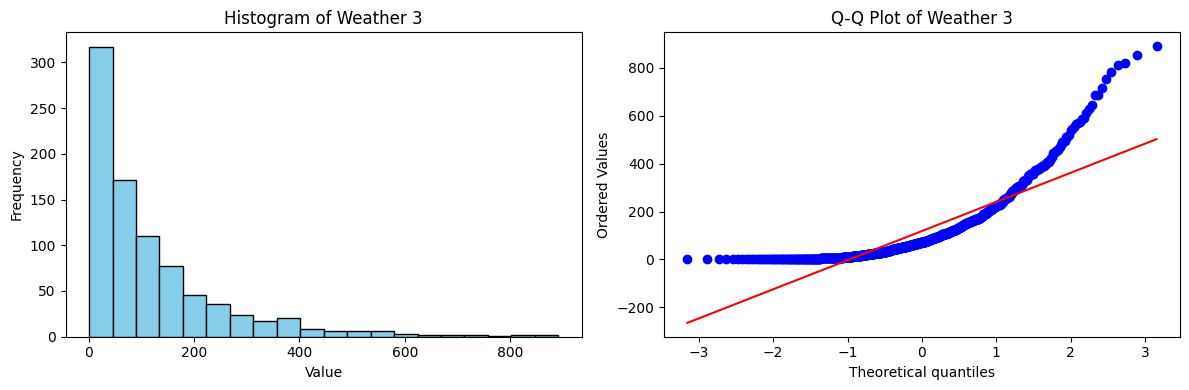

Skewness: 2.19
Kurtosis: 6.00
Shapiro-Wilk's Test p-value: 0.0000
The data does not look normally distributed (Reject the null hypothesis).
Normality Test for Weather 4:
Insufficient data points for normality test.


In [50]:
from scipy.stats import shapiro

# Define a function to check normality assumption
def check_normality(data, label):
    print(f"Normality Test for {label}:")

    # Check if data has at least 3 elements
    if len(data) < 3:
        print("Insufficient data points for normality test.")
        return

    # Histogram and Q-Q Plot
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(data, bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of {label}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {label}")

    plt.tight_layout()
    plt.show()

    # Skewness and Kurtosis
    skewness = data.skew()
    kurtosis = data.kurtosis()
    print(f"Skewness: {skewness:.2f}")
    print(f"Kurtosis: {kurtosis:.2f}")

    # Shapiro-Wilk's Test
    stat, p_value = shapiro(data)
    print(f"Shapiro-Wilk's Test p-value: {p_value:.4f}")
    if p_value > 0.05:
        print("The data looks normally distributed (Fail to reject the null hypothesis).")
    else:
        print("The data does not look normally distributed (Reject the null hypothesis).")

# Check normality assumption for each weather condition
check_normality(weather_1, "Weather 1")
check_normality(weather_2, "Weather 2")
check_normality(weather_3, "Weather 3")
check_normality(weather_4, "Weather 4")


In [51]:
from scipy.stats import levene

# Perform Levene's test for equality of variances
statistic, p_value = levene(weather_1, weather_2, weather_3, weather_4)

# Setting the significance level (alpha)
alpha = 0.05

# Printing the results
print("Levene's Test for Equality of Variances:")
print("Test Statistic:", statistic)
print("P-Value:", p_value)

# Decision
if p_value <= alpha:
    print("Reject Null Hypothesis (H0): The variances are not equal across different weather conditions.")
else:
    print("Fail to Reject Null Hypothesis (H0): The variances are equal across different weather conditions.")


Levene's Test for Equality of Variances:
Test Statistic: 54.85106195954556
P-Value: 3.504937946833238e-35
Reject Null Hypothesis (H0): The variances are not equal across different weather conditions.


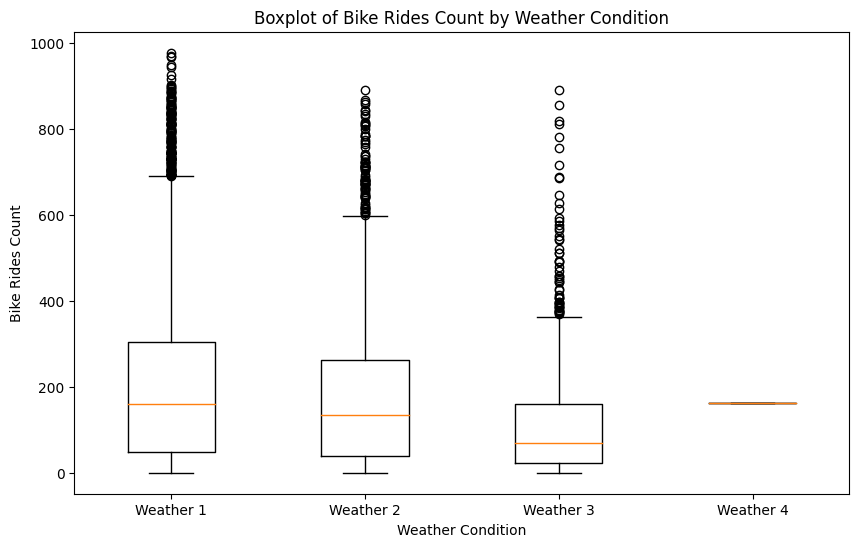

In [52]:
# Boxplot for each weather condition
plt.figure(figsize=(10, 6))
plt.boxplot([weather_1, weather_2, weather_3, weather_4], labels=["Weather 1", "Weather 2", "Weather 3", "Weather 4"])
plt.title("Boxplot of Bike Rides Count by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Bike Rides Count")
plt.show()


Conclusion:
Based on the results of the one-way ANOVA test and visual inspection, we can make informed decisions about the relationship between weather conditions and the demand for bicycles on rent.
The analysis indicates that the variances of the demand for bicycles on rent are significantly different across different weather conditions. This suggests that the variability in demand varies depending on the prevailing weather conditions. It's important to consider these differences when analyzing and interpreting the impact of weather on bicycle rental demand and when planning resource allocation and service management strategies.


In [54]:
from scipy.stats import f_oneway

# Extracting demand for bicycles on rent for different seasons
spring_counts = df[df['season'] == 1]['count']
summer_counts = df[df['season'] == 2]['count']
fall_counts = df[df['season'] == 3]['count']
winter_counts = df[df['season'] == 4]['count']

# Performing one-way ANOVA test
f_statistic, p_value = f_oneway(spring_counts, summer_counts, fall_counts, winter_counts)

# Setting the significance level (alpha)
alpha = 0.05

# Printing the results
print("One-way ANOVA Test for Seasons:")
print("F-Statistic:", f_statistic)
print("P-Value:", p_value)

# Decision
if p_value <= alpha:
    print("Reject Null Hypothesis (H0): The demand for bicycles on rent varies significantly across different seasons.")
else:
    print("Fail to Reject Null Hypothesis (H0): The demand for bicycles on rent is the same across different seasons.")


One-way ANOVA Test for Seasons:
F-Statistic: 236.94671081032106
P-Value: 6.164843386499654e-149
Reject Null Hypothesis (H0): The demand for bicycles on rent varies significantly across different seasons.


Normality Test for Spring:


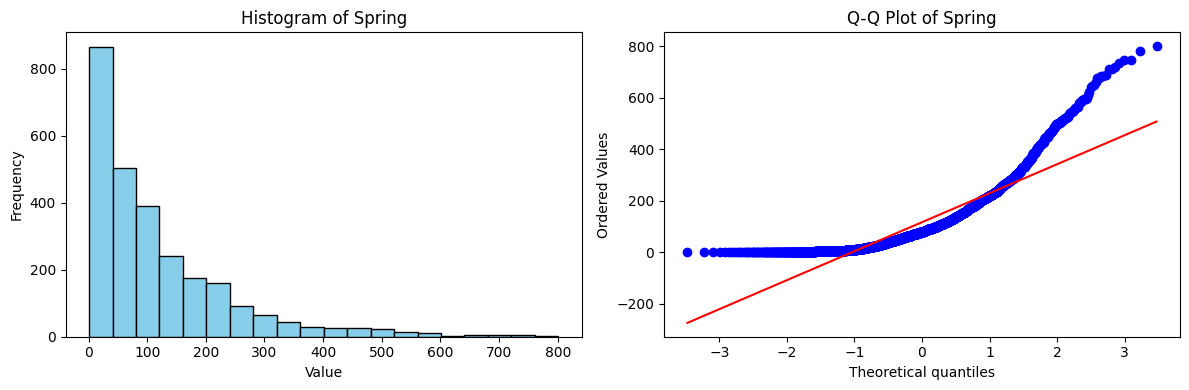

Skewness: 1.89
Kurtosis: 4.31
Shapiro-Wilk's Test p-value: 0.0000
The data does not look normally distributed (Reject the null hypothesis).
Normality Test for Summer:


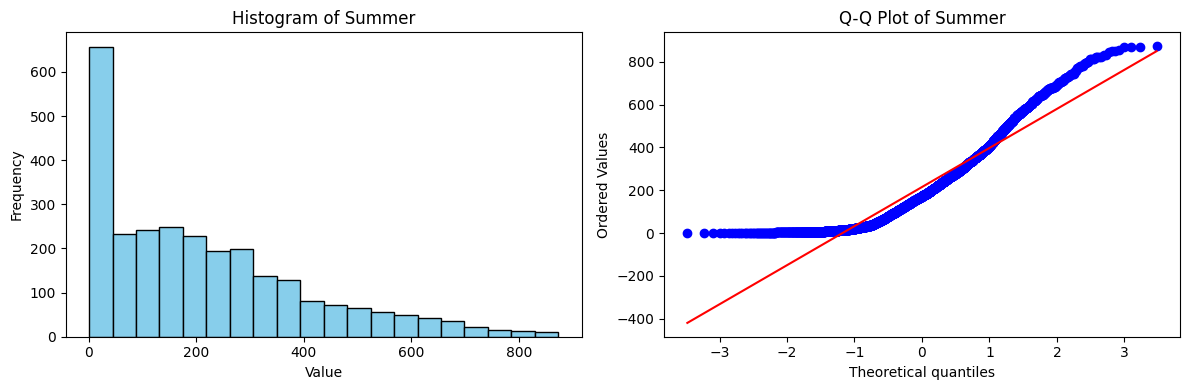

Skewness: 1.00
Kurtosis: 0.43
Shapiro-Wilk's Test p-value: 0.0000
The data does not look normally distributed (Reject the null hypothesis).
Normality Test for Fall:


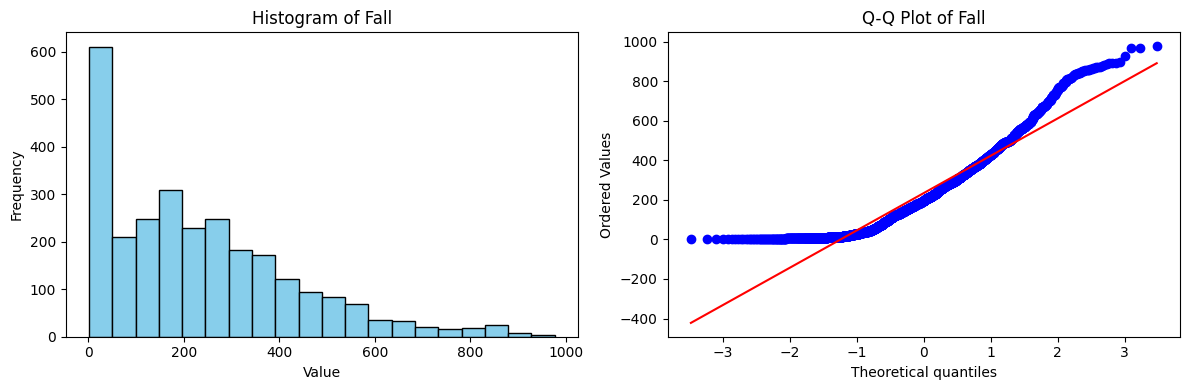

Skewness: 0.99
Kurtosis: 0.70
Shapiro-Wilk's Test p-value: 0.0000
The data does not look normally distributed (Reject the null hypothesis).
Normality Test for Winter:


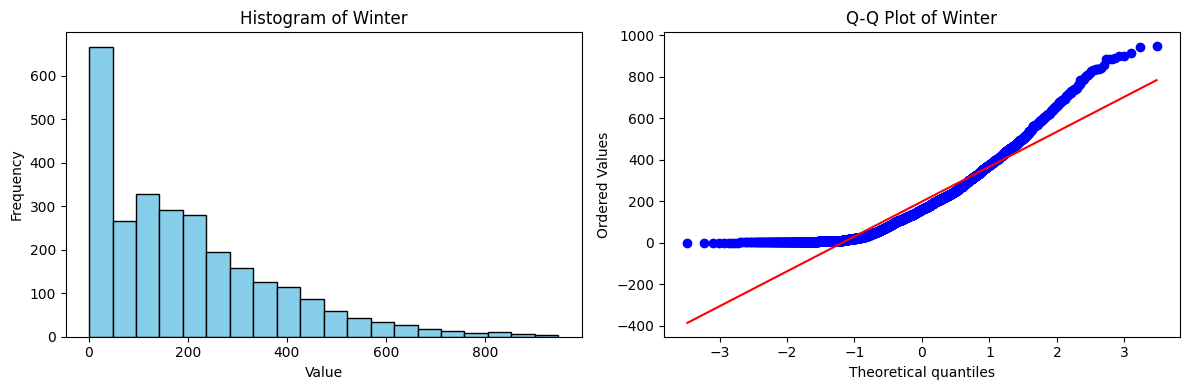

Skewness: 1.17
Kurtosis: 1.27
Shapiro-Wilk's Test p-value: 0.0000
The data does not look normally distributed (Reject the null hypothesis).


In [55]:
from scipy.stats import shapiro

# Define a function to check normality assumption
def check_normality(data, label):
    print(f"Normality Test for {label}:")

    # Histogram and Q-Q Plot
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(data, bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of {label}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {label}")

    plt.tight_layout()
    plt.show()

    # Skewness and Kurtosis
    skewness = data.skew()
    kurtosis = data.kurtosis()
    print(f"Skewness: {skewness:.2f}")
    print(f"Kurtosis: {kurtosis:.2f}")

    # Shapiro-Wilk's Test
    stat, p_value = shapiro(data)
    print(f"Shapiro-Wilk's Test p-value: {p_value:.4f}")
    if p_value > 0.05:
        print("The data looks normally distributed (Fail to reject the null hypothesis).")
    else:
        print("The data does not look normally distributed (Reject the null hypothesis).")

# Check normality assumption for each season
check_normality(spring_counts, "Spring")
check_normality(summer_counts, "Summer")
check_normality(fall_counts, "Fall")
check_normality(winter_counts, "Winter")


In [56]:
from scipy.stats import levene

# Perform Levene's test for equality of variances
statistic, p_value = levene(spring_counts, summer_counts, fall_counts, winter_counts)

# Setting the significance level (alpha)
alpha = 0.05

# Printing the results
print("Levene's Test for Equality of Variances:")
print("Test Statistic:", statistic)
print("P-Value:", p_value)

# Decision
if p_value <= alpha:
    print("Reject Null Hypothesis (H0): The variances are not equal across different seasons.")
else:
    print("Fail to Reject Null Hypothesis (H0): The variances are equal across different seasons.")

# Continue with one-way ANOVA test
f_statistic, p_value_anova = f_oneway(spring_counts, summer_counts, fall_counts, winter_counts)

# Printing the results of ANOVA test
print("\nOne-way ANOVA Test for Seasons:")
print("F-Statistic:", f_statistic)
print("P-Value:", p_value_anova)

# Decision
if p_value_anova <= alpha:
    print("Reject Null Hypothesis (H0): The demand for bicycles on rent varies significantly across different seasons.")
else:
    print("Fail to Reject Null Hypothesis (H0): The demand for bicycles on rent is the same across different seasons.")


Levene's Test for Equality of Variances:
Test Statistic: 187.7706624026276
P-Value: 1.0147116860043298e-118
Reject Null Hypothesis (H0): The variances are not equal across different seasons.

One-way ANOVA Test for Seasons:
F-Statistic: 236.94671081032106
P-Value: 6.164843386499654e-149
Reject Null Hypothesis (H0): The demand for bicycles on rent varies significantly across different seasons.


The analysis indicates that there is a significant difference in the demand for bicycles on rent across different seasons. Additionally, the variances of demand are not equal across seasons. This suggests that seasons have a substantial impact on the demand for bicycles, and different strategies may be required to manage and optimize bicycle rental services based on seasonal variations. Further exploration into the specific factors contributing to the seasonal variations in demand can provide valuable insights for planning and resource allocation.

In [60]:
from scipy.stats import chi2_contingency

# Encoding the 'Weather' and 'Season' columns as distinct categories
encoded_df = df.copy()
encoded_df['weather'] = encoded_df['weather'].astype('category').cat.codes
encoded_df['season'] = encoded_df['season'].astype('category').cat.codes

# Formulating the contingency table
contingency_table = pd.crosstab(encoded_df['weather'], encoded_df['season'])

# Performing chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Setting the significance level (alpha)
alpha = 0.05

# Printing the results
print("Chi-Square Test for Independence:")
print("Chi-Square Statistic:", chi2_stat)
print("P-Value:", p_value)

# Decision
if p_value <= alpha:
    print("Reject Null Hypothesis (H0): There is a significant difference in weather conditions during different seasons.")
else:
    print("Fail to Reject Null Hypothesis (H0): There is no significant difference in weather conditions during different seasons.")


Chi-Square Test for Independence:
Chi-Square Statistic: 49.15865559689363
P-Value: 1.5499250736864862e-07
Reject Null Hypothesis (H0): There is a significant difference in weather conditions during different seasons.


In [62]:
from scipy.stats import chi2_contingency

# Create a Contingency Table for 'Weather' and 'Season'
contingency_table = pd.crosstab(df['weather'], df['season'])

# Perform Chi-square Test for Independence
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Setting the significance level (alpha)
alpha = 0.05

# Printing the results
print("Chi-Square Test for Independence:")
print("Chi-Square Statistic:", chi2_stat)
print("P-Value:", p_value)

# Decision
if p_value <= alpha:
    print("Reject Null Hypothesis (H0): There is a significant difference in weather conditions during different seasons.")
else:
    print("Fail to Reject Null Hypothesis (H0): There is no significant difference in weather conditions during different seasons.")


Chi-Square Test for Independence:
Chi-Square Statistic: 49.15865559689363
P-Value: 1.5499250736864862e-07
Reject Null Hypothesis (H0): There is a significant difference in weather conditions during different seasons.


Conclusion:
Since the p-value is less than the significance level (alpha), we reject the null hypothesis, indicating that there is a significant difference in weather conditions during different seasons. The analysis suggests that there is a significant difference in weather conditions during different seasons. This implies that weather patterns vary across different seasons, which can have important implications for various sectors such as transportation, agriculture, tourism, and outdoor activities. Understanding these variations can help in making informed decisions and planning activities accordingly to mitigate potential risks and capitalize on opportunities associated with different weather conditions.